In [199]:
# Libaries
import matplotlib as mpl
import matplotlib.pyplot as plt
import scienceplots
from matplotlib.animation import FuncAnimation
from matplotlib.gridspec import GridSpec
plt.style.use(["science", "no-latex"])
import torch
import gpytorch
torch.set_default_dtype(torch.float64)
import numpy as np
import warnings
import os
import cv2
import numpy as np
import shutil
import pandas as pd


# SmallsatSim stuff
from smallsat_sim.utils.logger import Logger
import matplotlib.pyplot as plt

# Zero Order GPMPC package stuff
from zero_order_gpmpc.models.gpytorch_models.gpytorch_gp import (
    BatchIndependentMultitaskGPModel,
)

In [200]:
# Define some matplotlib parameters
# Use LaTeX for rendering text in plots
mpl.rcParams['text.usetex'] = True
mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['font.size'] = 12  # Adjust as needed
mpl.rcParams['axes.labelsize'] = 14
mpl.rcParams['axes.titlesize'] = 14
mpl.rcParams['legend.fontsize'] = 12
mpl.rcParams['xtick.labelsize'] = 12
mpl.rcParams['ytick.labelsize'] = 12

In [201]:
# Create Logger object (needed to load data)
logger = Logger()

# Load the pandas dataframe
df = logger.load_log()

# Print some information about the df
df.shape
df.info()
df.describe()

Loading log files from directory: /media/ahansson/2884-8728/logs/2024-10-21_20-38-12
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12020 entries, 0 to 12019
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   RunID             12020 non-null  int64  
 1   Timestamp         12020 non-null  float64
 2   perturbation_log  10 non-null     object 
 3   gp_GT             12020 non-null  object 
 4   gp_pred           12020 non-null  object 
 5   gp_lower          12020 non-null  object 
 6   gp_upper          12020 non-null  object 
 7   n_points_GP       12020 non-null  int64  
 8   tracking_error    12020 non-null  float64
 9   attitude_error    12020 non-null  float64
 10  solve_time        12020 non-null  int64  
 11  mpc_cost          12020 non-null  object 
 12  u_demanded        12020 non-null  object 
 13  velocity          12020 non-null  float64
 14  u_actual          12020 non-null  object 
 15  e_

,RunID,Timestamp,n_points_GP,tracking_error,attitude_error,solve_time,velocity,e_gp,e_nom
count,12020.000000,12020.000000,12020.000000,12020.000000,12020.000000,12020.0,12020.000000,1.201000e+04,1.201000e+04
mean,4.496256,60.050374,90.408153,0.354626,24.830408,0.0,0.185984,5.778035e-03,1.834750e-02
std,2.874136,34.700834,88.464242,1.190602,44.110641,0.0,0.054795,2.486924e-02,2.944867e-02
min,0.000000,0.000000,0.000000,0.000010,0.003206,0.0,0.000000,2.707260e-07,2.487189e-07
25%,2.000000,30.000000,28.000000,0.001318,0.343281,0.0,0.169794,1.690585e-05,9.907153e-04
50%,4.000000,60.050000,56.000000,0.009029,1.279173,0.0,0.199458,8.520050e-05,2.088436e-03
75%,7.000000,90.100000,122.000000,0.087160,28.259390,0.0,0.200430,5.845375e-04,4.165675e-02
max,9.000000,121.000000,300.000000,8.383210,179.872266,0.0,0.421796,8.249148e-01,1.938596e-01


In [202]:
# Calculate and print the mean tracking error of all run ids
mean_tracking_error = df.groupby("RunID")["tracking_error"].mean()



In [203]:
# Count how many runs violoate constraints
# Group by 'RunID' and check if any tracking error in that run is larger than 1m
run_ids_with_error_gt_1m = df.groupby('RunID')['tracking_error'].apply(lambda x: (x > 1).any())

# Getting the list of RunIDs where tracking error is larger than 1m
run_ids_with_error_gt_1m = run_ids_with_error_gt_1m[run_ids_with_error_gt_1m].index.tolist()

print(f'RunIDs with tracking error larger than 1m: {run_ids_with_error_gt_1m}')


RunIDs with tracking error larger than 1m: [1, 6]


RunID: 1
Maximum Tracking Error: 8.383209673324561 m
Number of Perturbations: 5
Perturbation Log: [(4, 2.9086988348478027, 'stuck_off'), (6, 2.9086988348478027, 'stuck_off'), (1, 36.528862757560184, 'faulty_valve (8.266218146755744, 0.5988002958198232)'), (8, 9.012698119848942, 'saturated_thrust'), (3, 17.395876016551348, 'saturated_thrust')]

RunID: 6
Maximum Tracking Error: 1.047155115574911 m
Number of Perturbations: 4
Perturbation Log: [(2, 20.519502615407085, 'stuck_off'), (1, 1.6772173374278498, 'faulty_valve (7.997946255972753, 0.5816231083953457)'), (8, 36.87728015544459, 'faulty_valve (0.054371809492373045, 0.27923307343213494)'), (9, 24.478628704131555, 'saturated_thrust')]



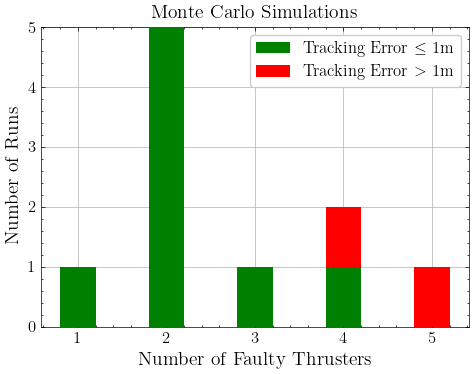

In [208]:
# Assuming 'df' is your DataFrame

# Step 1: Extract maximum tracking error per RunID
max_tracking_error = df.groupby('RunID')['tracking_error'].max().reset_index()
max_tracking_error.rename(columns={'tracking_error': 'max_tracking_error'}, inplace=True)

# Step 2: Extract perturbation logs at timestamp 0 for each RunID
perturbation_logs = df[df['Timestamp'] == 0.0][['RunID', 'perturbation_log']]

# Step 3: Merge the two DataFrames
merged_df = pd.merge(max_tracking_error, perturbation_logs, on='RunID', how='left')

# Step 4: Filter runs with tracking error > 1m
high_error_runs = merged_df[merged_df['max_tracking_error'] > 1.0]

# Step 5: Print the perturbation logs for these runs, including the number of perturbations
for idx, row in high_error_runs.iterrows():
    perturbation_log = row['perturbation_log']
    
    # Count the number of perturbations
    if perturbation_log is None:
        num_perturbations = 0
    elif isinstance(perturbation_log, float) and np.isnan(perturbation_log):
        num_perturbations = 0
    elif isinstance(perturbation_log, (list, tuple, np.ndarray)):
        num_perturbations = len(perturbation_log)
    elif isinstance(perturbation_log, str):
        try:
            perturbations = ast.literal_eval(perturbation_log)
            num_perturbations = len(perturbations)
        except (ValueError, SyntaxError):
            num_perturbations = 0
    else:
        # Handle unexpected data types
        num_perturbations = 0

    print(f"RunID: {row['RunID']}")
    print(f"Maximum Tracking Error: {row['max_tracking_error']} m")
    print(f"Number of Perturbations: {num_perturbations}")
    print(f"Perturbation Log: {perturbation_log}\n")


# Step 1: Define the function to count unique faulty thrusters (as before)
import ast
import numpy as np

def count_faulty_thrusters(log):
    if log is None:
        return 0
    if isinstance(log, float) and np.isnan(log):
        return 0
    if isinstance(log, (list, tuple, np.ndarray)):
        if len(log) == 0:
            return 0
        perturbations = log
    elif isinstance(log, str):
        try:
            perturbations = ast.literal_eval(log)
        except (ValueError, SyntaxError):
            return 0
    else:
        # If log is of an unexpected type, return 0
        return 0
    thrusters = set()
    for p in perturbations:
        try:
            thrusters.add(p[0])
        except (IndexError, TypeError):
            continue
    return len(thrusters)

# Step 2: Apply the function to count faulty thrusters
merged_df['num_faulty_thrusters'] = merged_df['perturbation_log'].apply(count_faulty_thrusters)

# Step 3: Categorize runs based on tracking error
merged_df['error_category'] = np.where(merged_df['max_tracking_error'] > 1.0, 'Above 1m', 'Below 1m')

# Step 4: Group data for the histogram
hist_data = merged_df.groupby(['num_faulty_thrusters', 'error_category']).size().unstack(fill_value=0).reset_index()

# Convert counts to integers
hist_data[['Above 1m', 'Below 1m']] = hist_data[['Above 1m', 'Below 1m']].astype(int)

# Step 5: Remove x entries where no data is available
# We only keep entries where the total count is greater than zero
hist_data['Total'] = hist_data['Above 1m'] + hist_data['Below 1m']
hist_data = hist_data[hist_data['Total'] > 0]

# Now, proceed to plot the histogram
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(5, 4))

bar_width = 0.4
index = np.arange(len(hist_data))

# Plot the stacked bars
ax.grid(zorder=0)
ax.bar(index, hist_data['Below 1m'], bar_width, label='Tracking Error $\leq$ 1m', color='green', zorder=3)
ax.bar(index, hist_data['Above 1m'], bar_width, bottom=hist_data['Below 1m'], label=r'Tracking Error $>$ 1m', color='red', zorder=3)

# Set labels and title
ax.set_xlabel('Number of Faulty Thrusters')
ax.set_ylabel('Number of Runs')
ax.set_title('Monte Carlo Simulations')
ax.set_xticks(index)
ax.set_xticklabels(hist_data['num_faulty_thrusters'].astype(int))
ax.legend(framealpha=1, frameon=True)


plt.tight_layout()
plt.show()


In [205]:
import pandas as pd
import numpy as np
import ast

# Assuming 'df' is your DataFrame

# Step 1: Exclude unsuccessful runs (tracking error above 1m)
max_tracking_error = df.groupby('RunID')['tracking_error'].max().reset_index()
max_tracking_error.rename(columns={'tracking_error': 'max_tracking_error'}, inplace=True)
successful_runids = max_tracking_error[max_tracking_error['max_tracking_error'] <= 1.0]['RunID'].unique()
df_successful = df[df['RunID'].isin(successful_runids)].copy()

# Step 2: Define a function to count unique faulty thrusters
def count_faulty_thrusters(log):
    if log is None or (isinstance(log, float) and np.isnan(log)):
        return 0
    try:
        if isinstance(log, str):
            perturbations = ast.literal_eval(log)
        elif isinstance(log, (list, tuple, np.ndarray)):
            perturbations = log
        else:
            return 0
        thrusters = set(p[0] for p in perturbations if isinstance(p, (list, tuple)) and len(p) > 0)
        return len(thrusters)
    except (ValueError, SyntaxError, TypeError):
        return 0

# Step 3: Get 'perturbation_log' at Timestamp == 0.0 per RunID
perturbation_logs = df[df['Timestamp'] == 0.0][['RunID', 'perturbation_log']]
perturbation_logs_successful = perturbation_logs[perturbation_logs['RunID'].isin(successful_runids)].copy()
perturbation_logs_successful['num_faulty_thrusters'] = perturbation_logs_successful['perturbation_log'].apply(count_faulty_thrusters)

# Step 4: Ensure 'e_gp' and 'e_nom' are numeric
df_successful['e_gp'] = pd.to_numeric(df_successful['e_gp'], errors='coerce')
df_successful['e_nom'] = pd.to_numeric(df_successful['e_nom'], errors='coerce')

# Step 5: Prepare 'mpc_cost' for computation
# Since 'mpc_cost' is numeric, we can proceed, but we need to handle NaNs
df_successful['mpc_cost'] = pd.to_numeric(df_successful['mpc_cost'], errors='coerce').fillna(0)

# Step 6: Define a function to compute 'mpc_cost_cumsum' per RunID
def compute_mpc_cost_cumsum(group):
    mpc_cost = group['mpc_cost'] + 0.2 * 5e-3
    cumsum = mpc_cost.cumsum()
    return cumsum.iloc[-1]

# Step 7: Compute 'mpc_cost_cumsum' per RunID
mpc_cost_cumsum = df_successful.groupby('RunID').apply(compute_mpc_cost_cumsum).reset_index(name='mpc_cost_cumsum')

# Step 8: Compute per RunID metrics
run_metrics = df_successful.groupby('RunID').agg({
    'tracking_error': 'mean',
    'attitude_error': 'mean',
    'e_gp': 'mean',
    'e_nom': 'mean'
}).reset_index().rename(columns={
    'tracking_error': 'tracking_error_mean',
    'attitude_error': 'attitude_error_mean',
    'e_gp': 'e_gp_mean',
    'e_nom': 'e_nom_mean'
})

# Merge 'mpc_cost_cumsum' into 'run_metrics'
run_metrics = run_metrics.merge(mpc_cost_cumsum, on='RunID', how='left')

# Merge 'num_faulty_thrusters' into 'run_metrics'
run_metrics = run_metrics.merge(perturbation_logs_successful[['RunID', 'num_faulty_thrusters']], on='RunID', how='left')

# Step 9: Group 'run_metrics' by 'num_faulty_thrusters' and compute the required metrics
table = run_metrics.groupby('num_faulty_thrusters').agg({
    'RunID': 'count',
    'tracking_error_mean': 'mean',
    'attitude_error_mean': 'mean',
    'mpc_cost_cumsum': 'mean',
    'e_gp_mean': 'mean',
    'e_nom_mean': 'mean'
}).reset_index().rename(columns={'RunID': 'Number of Runs'})

# Step 10: Convert 'num_faulty_thrusters' to string to include 'Average' row
table['num_faulty_thrusters'] = table['num_faulty_thrusters'].astype(str)

# Step 11: Compute the overall averages (last row)
overall_averages = pd.DataFrame({
    'num_faulty_thrusters': ['Average'],
    'Number of Runs': [run_metrics['RunID'].nunique()],
    'tracking_error_mean': [run_metrics['tracking_error_mean'].mean()],
    'attitude_error_mean': [run_metrics['attitude_error_mean'].mean()],
    'mpc_cost_cumsum': [run_metrics['mpc_cost_cumsum'].mean()],
    'e_gp_mean': [run_metrics['e_gp_mean'].mean()],
    'e_nom_mean': [run_metrics['e_nom_mean'].mean()]
})

# Step 12: Concatenate 'table' and 'overall_averages'
table = pd.concat([table, overall_averages], ignore_index=True)

# Step 13: Set 'num_faulty_thrusters' as the index
table.set_index('num_faulty_thrusters', inplace=True)

# Step 14: Ensure that numeric columns are of numeric type
numeric_cols = ['Number of Runs', 'tracking_error_mean', 'attitude_error_mean', 'mpc_cost_cumsum', 'e_gp_mean', 'e_nom_mean']
for col in numeric_cols:
    table[col] = pd.to_numeric(table[col], errors='coerce')

# Step 15: Round numerical columns for better readability
table_rounded = table.copy()
table_rounded[numeric_cols] = table_rounded[numeric_cols].round(6)

# Step 16: Display the table in a pretty format
from tabulate import tabulate
print(tabulate(table_rounded.reset_index(), headers='keys', tablefmt='psql'))

# Step 17: Export the table to LaTeX
latex_table = table.to_latex(float_format="%.6f", index=True)
print(latex_table)


+----+------------------------+------------------+-----------------------+-----------------------+-------------------+-------------+--------------+
|    | num_faulty_thrusters   |   Number of Runs |   tracking_error_mean |   attitude_error_mean |   mpc_cost_cumsum |   e_gp_mean |   e_nom_mean |
|----+------------------------+------------------+-----------------------+-----------------------+-------------------+-------------+--------------|
|  0 | 1                      |                1 |              0.012021 |               2.03831 |           1.201   |    6.8e-05  |     0.003639 |
|  1 | 2                      |                5 |              0.029782 |               6.28506 |           1.201   |    0.000849 |     0.007563 |
|  2 | 3                      |                1 |              0.142304 |              23.2158  |           1.211   |    0.000664 |     0.016256 |
|  3 | 4                      |                1 |              0.068481 |              11.1585  |           1.2

/tmp/ipykernel_517241/1176743657.py:49: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  mpc_cost_cumsum = df_successful.groupby('RunID').apply(compute_mpc_cost_cumsum).reset_index(name='mpc_cost_cumsum')


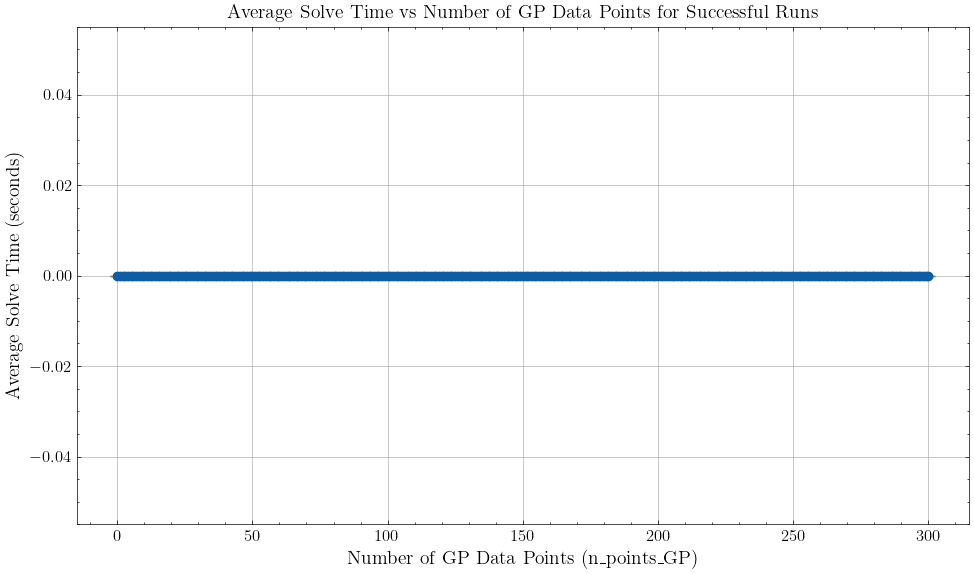

In [210]:
# Assuming 'df' is your DataFrame and 'df_successful' contains successful runs as defined earlier.

# Step 1: Ensure 'n_points_GP' and 'solve_time' are numeric
df_successful['n_points_GP'] = pd.to_numeric(df_successful['n_points_GP'], errors='coerce')
df_successful['solve_time'] = pd.to_numeric(df_successful['solve_time'], errors='coerce')

# Step 2: Remove any rows with NaN values in 'n_points_GP' or 'solve_time'
df_successful_clean = df_successful.dropna(subset=['n_points_GP', 'solve_time'])

# Step 3: Compute mean and standard deviation of 'solve_time' per 'n_points_GP'
n_points_gp_stats = df_successful_clean.groupby('n_points_GP')['solve_time'].agg(['mean', 'std', 'count']).reset_index()

# Step 4: Plot 'n_points_GP' vs average 'solve_time' with standard deviation error bars
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# Plot with error bars
plt.errorbar(
    n_points_gp_stats['n_points_GP'],
    n_points_gp_stats['mean'],
    yerr=n_points_gp_stats['std'],
    fmt='o-',  # Format line with circle markers
    capsize=5,  # Adds caps to the error bars
    ecolor='gray',  # Error bar color
    elinewidth=1,  # Error bar line width
    markeredgewidth=1  # Marker edge width
)

plt.xlabel('Number of GP Data Points (n_points_GP)')
plt.ylabel('Average Solve Time (seconds)')
plt.title('Average Solve Time vs Number of GP Data Points for Successful Runs')
plt.grid(True)
plt.tight_layout()
plt.show()
